In [1]:
!pip install shap

Import Libraries

In [14]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

import shap
import matplotlib.pyplot as plt

Load Dataset

In [6]:
from google.colab import files

# Upload the file if it's not already present
# If you've already uploaded the file in a previous run, you might not need to run this again.
# If the file is in a specific folder, replace 'loan_data.csv' with the correct path, e.g., 'data/loan_data.csv'
# To upload, uncomment the next two lines and run the cell, then select your file.
uploaded = files.upload()
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

data = pd.read_csv("loan_approval_dataset.csv")

print(data.head())

Saving loan_approval_dataset.csv to loan_approval_dataset (1).csv
User uploaded file "loan_approval_dataset (1).csv" with length 380211 bytes
   Applicant_ID  Age  Income  Credit_Score  Loan_Amount  Loan_Term  \
0             1   56   21920           639       452748         72   
1             2   69  126121           655       257134         60   
2             3   46   96872           467       226437         72   
3             4   32  101132           751       310480         12   
4             5   60   22093           404        13070         12   

   Interest_Rate Employment_Status  Debt_to_Income_Ratio Marital_Status  \
0           4.53        Unemployed                 43.35        Married   
1           5.38        Unemployed                 10.42       Divorced   
2           3.46     Self-Employed                 45.39       Divorced   
3          14.00        Unemployed                  8.58         Single   
4           9.13     Self-Employed                 20.70      

Handle Categorical Data

In [17]:
le = LabelEncoder()

for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = le.fit_transform(data[column])

In [25]:
X = data.drop("Previous_Defaults", axis=1)
y = data["Previous_Defaults"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train-Test split


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Training the Machine Learning Model

In [21]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

Making Predictions

In [22]:
predictions = model.predict(X_test)

print(predictions[:10])

[0 0 0 0 0 0 0 0 0 0]


Creating SHAP Explainer

In [23]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

Global Feature Importance

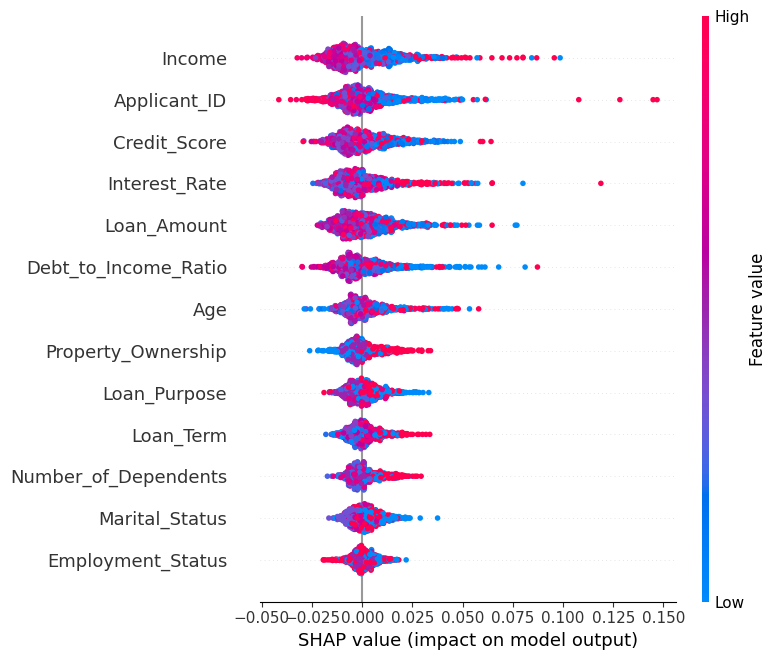

In [26]:
shap.summary_plot(shap_values[:, :, 1], X_test)

Explaining a Single Prediction

In [28]:
shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_values[0, :, 1],
    X_test.iloc[0]
)

Featuring Importance Plot

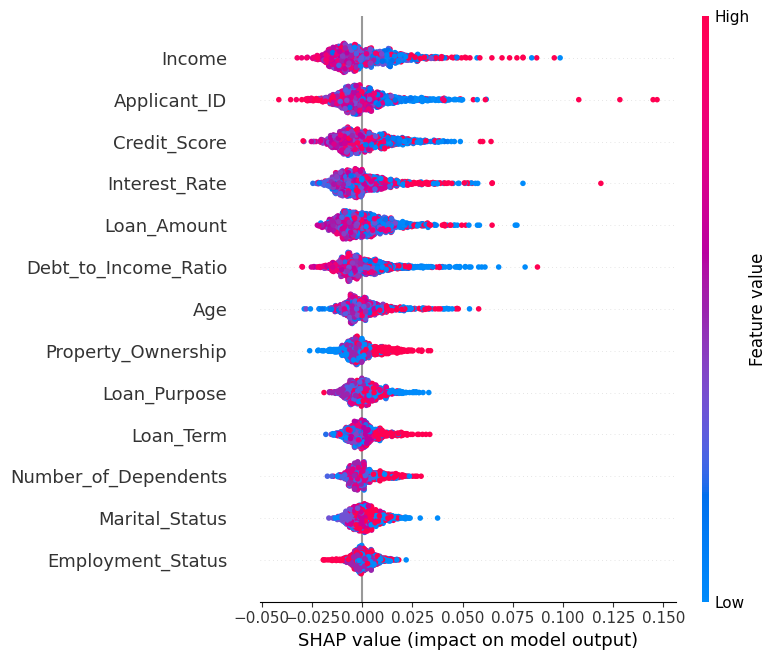

In [30]:
shap.summary_plot(shap_values[:, :, 1], X_test)

Bar Plot for Global Importance

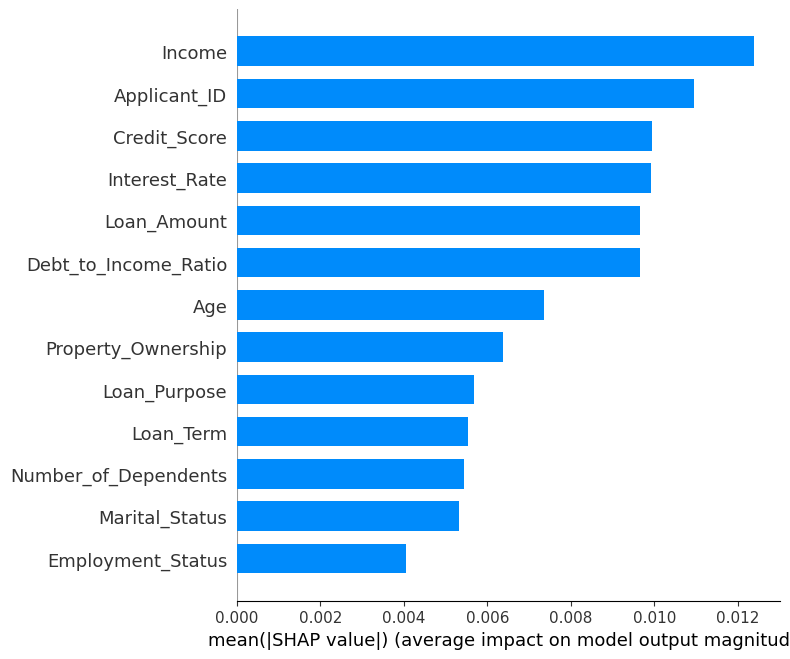

In [32]:
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar")

Dependence Plot

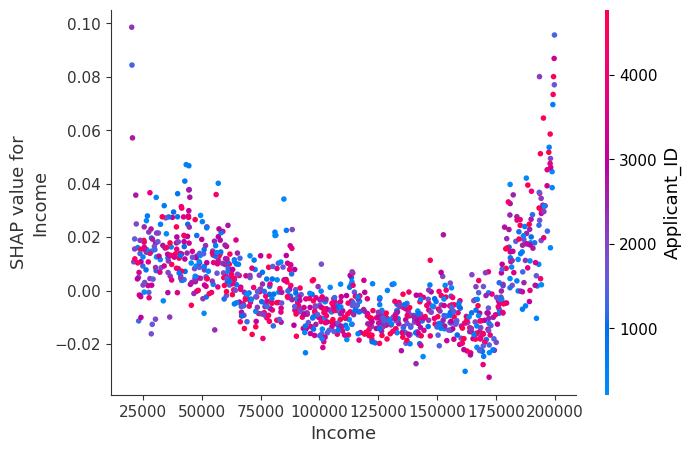

In [37]:
shap.dependence_plot("Income", shap_values[:, :, 1], X_test)

Evaluating Model Accuracy

In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.907


Model Comparison

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    print(name, "Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.907
Decision Tree Accuracy: 0.809
Random Forest Accuracy: 0.907


Selecting the Best Model

In [40]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()